

## Práctica 2: Propiedades estadísticas del lenguaje y Diversidad

### Fecha de entrega: 17 de Marzo de 2026 11:59pm 

Importamos las bibliotecas:


In [216]:
import random
import string
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
import plotly.express as px
import plotly.graph_objects as go


### 1. Verificación empírica de la Ley de Zipf

Verificar si la ley de Zipf se cumple en los siguientes casos:



1. En un lenguaje artificial creado por ustedes.
    * Creen un script que genere un texto aleatorio seleccionando caracteres al azar de un alfabeto definido. 
        * **Nota:** Asegúrense de incluir el carácter de "espacio" en su alfabeto para que el texto se divida en "palabras" de longitudes variables.
    * Obtengan las frecuencias de las palabras generadas para este texto artificial

* Estima el parámetro $\alpha$ que mejor se ajuste a la curva
* Generen las gráficas de rango vs. frecuencia (en escala y logarítmica).
    * Incluye la recta aproximada por $\alpha$
* ¿Se aproxima a la ley de Zipf? Justifiquen su respuesta comparándolo con el comportamiento del corpus visto en clase.

Comenzamos generando el lenguaje artificial con un script sobre el alfabeto descrito por caracteres ASCII.


In [217]:
def genera_palabra(longitud):
    """
    Función que genera una palabra aleatoria de una longitud utilizando
    los caracteres ASCII correspondientes a letras.

    Parametros:
    longitud (int): La longitud de la palabra a generar.
    
    Retorno:
    Una palabra aleatoria formada por caracteres correspondientes a letras
    en ASCII
    """
    return ''.join(random.choices(string.ascii_letters + " "  , k=longitud))


In [218]:
palabra_ejemplo = genera_palabra(5)
print(palabra_ejemplo)

PIpuS


Ahora, generamos una lista de palabras enorme con longitudes aleatorias.

In [219]:
def generar_vocabulario(longitud):
    """
    Función que genera un vocabulario de palabras aleatorias de una longitud dada.

    Parametros:
    longitud (int): La longitud del vocabulario a generar.
    
    Retorno:
    Un conjunto de palabras aleatorias formadas por caracteres correspondientes a letras
    en ASCII.   
    """
    vocabulario = set()
    while len(vocabulario) < longitud:
        random_int = random.randint(0, 10)
        palabra = genera_palabra(random_int)
        vocabulario.add(palabra)
    # Agregamos el espacio al vocabulario para que pueda ser utilizado como separador de palabras.
    vocabulario.add(' ')
    return vocabulario

In [220]:
vocabulario = generar_vocabulario(4000)
print(list(vocabulario)[:20])

['', ' JheCGT', 'XSQLcC', 'FmqciyoS', 'meijzsq', 'cTjc', 'bjMIxK', 'bQ BiQRv', 'StTUK', 'mG ', 'bxmAQZUXS', 'ImfOVNUwRR', 'mklPaBZn', 'DIOkKTM', 'iWb', 'EFhHO', 'KpcYyZgJv', 'pHOmWPAyo', 'ptsEfhppv', 'nLl']


Ahora, generamos un corpus de palabras tomadas del vocabulario que generamos.


In [221]:
corpus = random.choices(list(vocabulario), k=1000000)


Obtenemos el vocabulario con las frecuencias de cada palabra en el corpus. Para esto, utilizamos la clase Counter de la biblioteca collections, que nos permite contar la frecuencia de cada elemento en una lista. Luego, convertimos el resultado a un diccionario para facilitar su uso posterior.

Con esta muestra, contamos cuales son las palabras que más se repiten:

In [222]:
vocabulario_count = Counter(corpus)
vocabulario_count.most_common(10)

[('BjLzzfrrR', 299),
 ('VeYJmBzz', 299),
 ('MaMY', 299),
 ('yInqERi', 298),
 ('Pygd', 298),
 ('OofSIxTd', 298),
 ('oQkNM', 298),
 ('pI', 298),
 ('kInC', 296),
 ('sBaXJNKE', 296)]

In [223]:
def get_frequencies(vocabulary: Counter, n: int) -> list:
    return [_[1] for _ in vocabulary.most_common(n)]


def plot_frequencies(frequencies: list, title="Freq of words", log_scale=False):
    x = list(range(1, len(frequencies) + 1))
    plt.plot(x, frequencies, "-v")
    plt.xlabel("Freq rank (r)")
    plt.ylabel("Freq (f)")
    if log_scale:
        plt.xscale("log")
        plt.yscale("log")
    plt.title(title)

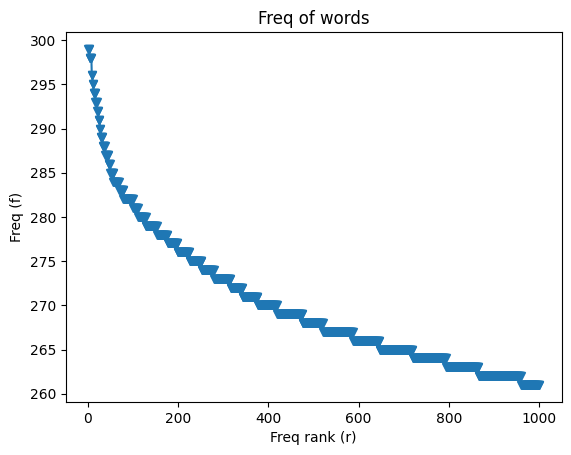

In [224]:
frequencies = get_frequencies(vocabulario_count, 1000)
plot_frequencies(frequencies)

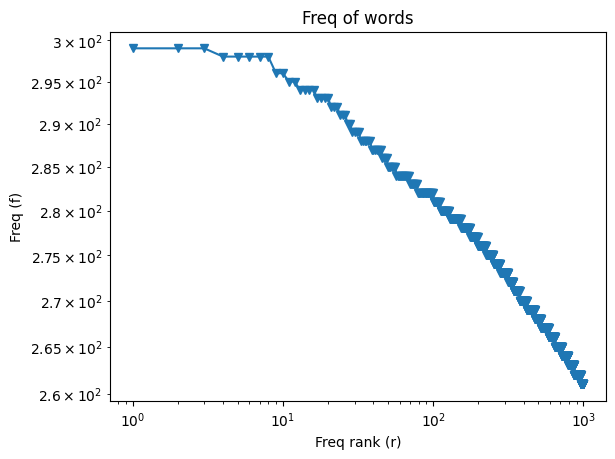

In [225]:
plot_frequencies(frequencies, log_scale=True)

In [226]:
import pandas as pd


def counter_to_pandas(counter: Counter) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(counter, orient="index").reset_index()
    df.columns = ["word", "count"]
    df.sort_values("count", ascending=False, inplace=True)
    df.reset_index(inplace=True, drop=True)
    return df

In [227]:
corpus_freqs = counter_to_pandas(vocabulario_count)

Ahora, reciclando el codigo aproximamos el valor de $\alpha$ a partir del codigo que hace la regresión lineal minimizando la suma de los errores cuadráticos:

In [228]:
# Obtenemos los ranks y las frecuencias del corpus
# +1 para hacer que los ranks inicien en 1 y no en 0
ranks = np.array(corpus_freqs.index) + 1
frequencies = np.array(corpus_freqs["count"])


def zipf_minimization_objective(
    alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray
) -> np.float64:
    """
    Calculate the sum of squared errors for Zipf's law fit.

    Parameters
    ----------
    alpha : np.float64
        The exponent parameter to optimize in Zipf's law
    word_ranks : np.ndarray
        Array of word ranks (1 = most frequent word)
    word_frequencies : np.ndarray
        Array of observed word frequencies

    Returns
    -------
    np.float64
        Sum of squared errors between log frequencies and Zipf's law prediction
    """
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)


In [229]:
initial_alpha_guess = 1.0

optimization_result = minimize(
    zipf_minimization_objective, initial_alpha_guess, args=(ranks, frequencies)
)
estimated_alpha = optimization_result.x[0]

mean_squared_error = zipf_minimization_objective(estimated_alpha, ranks, frequencies)
print(
    f"Estimated alpha: {estimated_alpha:.4f}\nMean Squared Error: {mean_squared_error:.4f}"
)


Estimated alpha: 0.0254
Mean Squared Error: 7.3652


Ahora graficamos el resultado en el espacio log-log, agregando el parámetro $\alpha$ para verificar que el lenguaje aleatorio cumple con la Ley de Zipf.

In [230]:
def plot_generate_zipf(alpha: np.float64, ranks: np.ndarray, freqs: np.ndarray) -> None:
    plt.plot(
        np.log(ranks),
        np.log(freqs[0]) - alpha * np.log(ranks),
        color="r",
        label="Aproximación Zipf",
    )

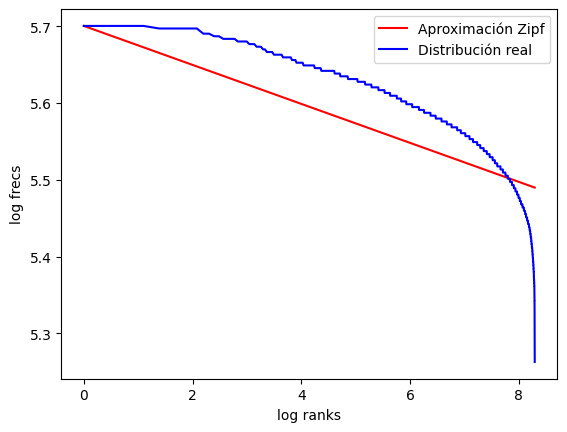

In [231]:
plot_generate_zipf(estimated_alpha, ranks, frequencies)
plt.plot(np.log(ranks), np.log(frequencies), color="b", label="Distribución real")
plt.xlabel("log ranks")
plt.ylabel("log frecs")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()



Vemos que definitivamente nuestro lenguaje generado aleatoriamente no cumple con la Ley de Zipf, a partir de la gráfica vemos que no existe la relación lineal tan marcada que caracteriza a los lenguajes que si cumplen la Ley de Zipf. Además, es claro que el lenguaje artificial no cumpliría la Ley de Zipf pues las palabras no tienen realmente una función en el texto que influya en la frecuencia del uso de las mismas.


2. Alguna lengua de bajos recursos digitales (*low-resourced language*)
    * Busca un corpus de libre acceso en alguna lengua de bajos recursos digitales
    * Obten las frecuencias de sus palabras

* Estima el parámetro $\alpha$ que mejor se ajuste a la curva
* Generen las gráficas de rango vs. frecuencia (en escala y logarítmica).
    * Incluye la recta aproximada por $\alpha$
* ¿Se aproxima a la ley de Zipf? Justifiquen su respuesta comparándolo con el comportamiento del corpus visto en clase.

> [!TIP]
> Puedes utilizar los corpus del paquete [`py-elotl`](https://pypi.org/project/elotl/)


Comenzamos obteniendo el corpus del paquete py-elotl.

In [232]:
%pip install elotl

Note: you may need to restart the kernel to use updated packages.


Trabajamos con el corpus tsunkua que describe algunas relaciones entre español y otomí, para el trabajo deberemos limpiarlo para que solo analicemos los textos en otomí.

In [233]:
import elotl.corpus 
tsunkua = elotl.corpus.load('tsunkua')
len(tsunkua)

4963

In [234]:
tsunkua[:5]

[['Arde, se calcina su corazón y su cuerpo está doliente. De igual modo a mí me arde y se calcina mi corazón.',
  "Zo̱, da zot'i ri ndäte ne ri ngo̱k'ei yabu̱ xa ñ'u̱. Mahye̱gi nugi zo̱ ne da zät'i ma ndäte.",
  'Otomí del Mezquital (ote)',
  'Visión de los vencidos (hñahñu)',
  'visiondelosvencidoshnahnu.pdf',
  '5c8a6eb3656c6f188d010000'],
 ['Luego ya vienen, de nuevo vienen en seguimiento de Citlaltépec. A Tlacopan. Allí se establecen en el Palacio.',
  "Ebu̱ ba ehe man'aki ba te̱nga ra t'o̱ho̱  ra thuhu ra Citlaltépec. Tlacopan, Nubia ba o̱t'ra b'u̱i ha ra ndo̱m'ihmu.",
  'Otomí del Mezquital (ote)',
  'Visión de los vencidos (hñahñu)',
  'visiondelosvencidoshnahnu.pdf',
  '5c8a6eb3656c6f188d010000'],
 ['y mirad que no lo descubráis a hijo de madre, so pena de las graves penas de tirar hasta los cimientos de casas,',
  'y mirad que no lo descubráis a hijo de madre, so pena de las graves penas de tirar hasta los cimientos de casas,',
  'Otomí del Mezquital (ote)',
  'Visión de los v

Limpiamos el corpus para quedarnos unicamente con los textos en la lengua que estamos analizando, ignorando el texto en español, quedandonos unicamente con el texto en la fila 2.

In [235]:
def limpia_corpus(corpus):
    return [linea[1] for linea in corpus if len(linea) > 1]
corpus_limpio = limpia_corpus(tsunkua)
corpus_limpio[:5]

["Zo̱, da zot'i ri ndäte ne ri ngo̱k'ei yabu̱ xa ñ'u̱. Mahye̱gi nugi zo̱ ne da zät'i ma ndäte.",
 "Ebu̱ ba ehe man'aki ba te̱nga ra t'o̱ho̱  ra thuhu ra Citlaltépec. Tlacopan, Nubia ba o̱t'ra b'u̱i ha ra ndo̱m'ihmu.",
 'y mirad que no lo descubráis a hijo de madre, so pena de las graves penas de tirar hasta los cimientos de casas,',
 "Di geb'u̱, ba ehe̱ n'a ra m'e̱hni ra bo̱nahmu nuni Acolhuacan, mra tuhu ra Tecocoltzin. Nu'u̱ bi ñ'ehe da ñäui ko ya jä'i mi ñ'ehe nuni Tlatelolco ge nuya:",
 '"Nu\'a dra t\'o̱t\'ai ra b\'e̱go, gri j\'äi ma n\'a:']

Ahora el corpus limpio lo tokenizamos, cuidando conservar los acentos ' que son parte de la estructura de la lengua.

In [236]:
import re
import pandas as pd
from collections import Counter

frases_otomi = corpus_limpio
todas_las_palabras = []

for frase in frases_otomi:
    # Pasar a minúsculas y estandarizar los '.
    frase = frase.lower().replace('’', "'").replace('‘', "'")
    
    # Quitar puntuación sin quitar el acento ' )
    frase_limpia = re.sub(r'[.,;:!?¿¡"“”()]', '', frase)
    
    # Separamos por espacios para obtener las palabras individuales.
    palabras = frase_limpia.split()
    
    # Agregar las palabras de esta frase a la lista de palabras.
    todas_las_palabras.extend(palabras)

# Usamos counter para obtener las palabras más frecuentes y su conteo.
vocabulario_tsunkua = Counter(todas_las_palabras)

# Convertimos el conteo en un DataFrame de Pandas.
df_frecuencias = pd.DataFrame(vocabulario_tsunkua.items(), columns=['Palabra', 'Frecuencia'])
# Ordenamos las frecuencias de mayor a menor.
df_frecuencias = df_frecuencias.sort_values(by='Frecuencia', ascending=False).reset_index(drop=True)
print(df_frecuencias.head(10))

  Palabra  Frecuencia
0      ra        5757
1      ya        3777
2      bi        2134
3      mi        1752
4      ne        1119
5      da        1047
6      ha         954
7      ma         744
8     n'a         736
9      pa         705


Ahora graficamos utilizando las funciones de la clase:

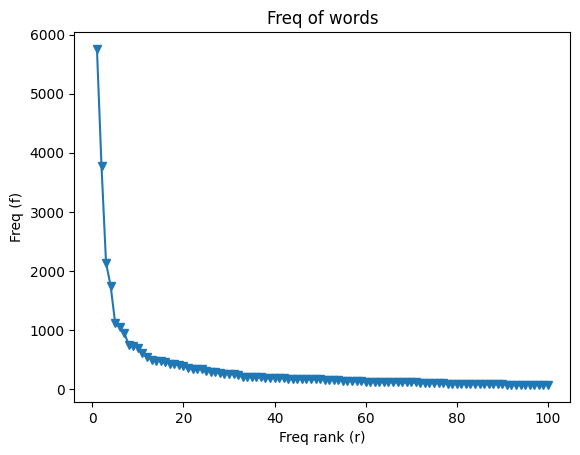

In [237]:
frequencies = get_frequencies(vocabulario_tsunkua, 100)
plot_frequencies(frequencies)

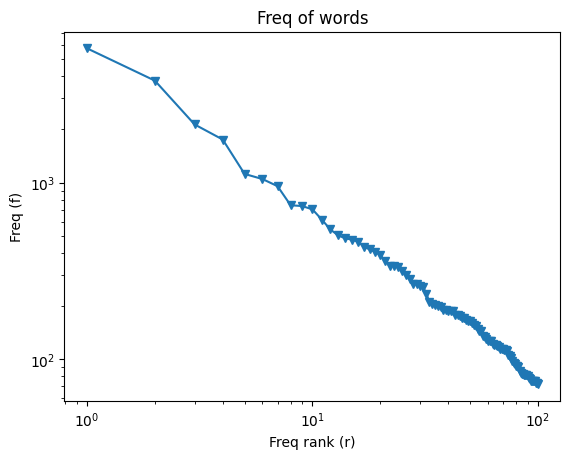

In [238]:
plot_frequencies(frequencies, log_scale=True)

Obtenemos la aproximación del parámetro $\alpha$.


In [239]:
# Obtenemos los ranks y las frecuencias del corpus
# +1 para hacer que los ranks inicien en 1 y no en 0
ranks = np.array(df_frecuencias.index) + 1
frequencies = np.array(df_frecuencias["Frecuencia"])

In [240]:
initial_alpha_guess = 1.0

optimization_result = minimize(
    zipf_minimization_objective, initial_alpha_guess, args=(ranks, frequencies)
)
estimated_alpha = optimization_result.x[0]

mean_squared_error = zipf_minimization_objective(estimated_alpha, ranks, frequencies)
print(
    f"Estimated alpha: {estimated_alpha:.4f}\nMean Squared Error: {mean_squared_error:.4f}"
)


Estimated alpha: 1.0035
Mean Squared Error: 560.7665


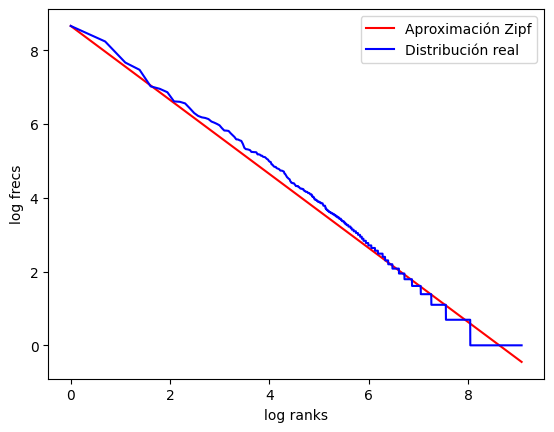

In [241]:
plot_generate_zipf(estimated_alpha, ranks, frequencies)
plt.plot(np.log(ranks), np.log(frequencies), color="b", label="Distribución real")
plt.xlabel("log ranks")
plt.ylabel("log frecs")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()


Podemos ver que en este caso la relación lineal se conserva bastante mejor, con lo que podemos decir que el corpus tsunkua, que contiene texto en otomí, cumple con la Ley de Zipf como lo esperariamos de un lenguaje real que posee cierta estructura. Por ejemplo, podemos ver también que las frases más comunes son de las más cortas y esto es un fenómeno que también comentabamos en clase.


### 2. Visualizando la diversidad lingüística de México

1. Usando los datos de Glottolog filtralos con base en la región geográfica que corresponde a México
    - Usa las columnas `"longitude"` y `"latitude"`
2. Realiza un plot de las lenguas por región de un mapa
    - Utiliza un color por familia linguistica en el mapa
3. Haz lo mismo para otro país del mundo

Responde las preguntas:

- ¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?
- ¿Cuál es la zona que dirias que tiene mayor diversidad en México?

> [!TIP]
> Utiliza la biblioteca [`plotly`](https://plotly.com/python/getting-started/) para crear mapa interactivos

### EXTRA. Desempeño de NER en distintos dominios (Out-of-domain)

Explorar la plataforma [Hugging Face Datasets](https://huggingface.co/datasets) y elegir documentos en Español provenientes de al menos 3 dominios muy distintos (ej. noticias, artículos médicos, tweets/redes sociales, foros legales).
* Realizar Reconocimiento de Entidades Nombradas (NER) en muestras de cada dominio utilizando spaCy o la herramienta de su preferencia.
* Mostrar una distribución de frecuencias de las etiquetas (PER, ORG, LOC, etc.) más comunes por dominio.
* **Análisis:** Incluyan comentarios críticos sobre el desempeño observado. ¿En qué dominio el modelo cometió más errores y a qué creen que se deba estadísticamente?

> [!TIP]
> Utiliza bibliotecas con modelos preentrenados que te permitan realizar el etiquetado NER como [`spacy`](https://spacy.io/usage) o [`stanza`](https://stanfordnlp.github.io/stanza/#getting-started).


### 2. Visualizando la diversidad lingüística de México

1. Usando los datos de Glottolog filtralos con base en la región geográfica que corresponde a México
    - Usa las columnas `"longitude"` y `"latitude"`

Descargamos los datos de Glottolog:

In [242]:
import os

# Se asume que se han descargado los archivo y que se encuentra en la carpeta data/
DATA_PATH = "data"
LANG_GEO_FILE = "languages_and_dialects_geo.csv"
LANGUOID_FILE = "languoid.csv"

In [243]:
languages = pd.read_csv(os.path.join(DATA_PATH, LANG_GEO_FILE))

In [244]:
languages.head()

,glottocode,name,isocodes,level,macroarea,latitude,longitude
0,3adt1234,3Ad-Tekles,NaN,dialect,Africa,NaN,NaN
1,aala1237,Aalawa,NaN,dialect,Papunesia,NaN,NaN
2,aant1238,Aantantara,NaN,dialect,Papunesia,NaN,NaN
3,aari1239,Aari,aiw,language,Africa,5.95034,36.5721
4,aari1240,Aariya,aay,language,Eurasia,NaN,NaN


In [245]:
languoids = pd.read_csv(os.path.join(DATA_PATH, LANGUOID_FILE))

In [246]:
min_lat = 14.32
max_lat = 32.43
min_long = -118.27
max_long = -86.42

mexico_languages = languages[
    (languages["latitude"] >= min_lat)
    & (languages["latitude"] <= max_lat)
    & (languages["longitude"] >= min_long)
    & (languages["longitude"] <= max_long)
]

In [247]:
mexico_languages.head()

,glottocode,name,isocodes,level,macroarea,latitude,longitude
78,acat1239,Acatepec Me'phaa,tpx,language,North America,17.1034,-99.0602
86,achi1256,Achi,acr,language,North America,15.0730,-90.3513
105,adai1235,Adai,xad,language,North America,31.6314,-92.0059
180,afro1254,Afro-Seminole Creole,afs,language,North America,31.7843,-99.2934
221,agua1252,Aguacateco,agu,language,North America,15.3307,-91.3153


In [248]:
languoids_dict = languoids.set_index("id").to_dict("index")


def reconstruir_linaje(glottocode):
    """Sube por el árbol genealógico desde la lengua hasta la familia raíz."""
    linaje = []
    current_id = glottocode

    # Mientras el ID actual exista y no sea nulo (NaN)
    while pd.notna(current_id) and current_id in languoids_dict:
        nodo = languoids_dict[current_id]

        # Filtramos lenguas artificiales o "bookkeeping"
        if nodo.get("bookkeeping") or nodo.get("name") == "Unclassifiable":
            return "Unclassifiable"

        # Insertamos el nombre al inicio de la lista para mantener el orden (Raíz -> Lengua)
        linaje.insert(0, str(nodo["name"]))

        # Subimos al nodo padre
        current_id = nodo["parent_id"]

    return " > ".join(linaje)

In [249]:
# Aplicamos la función a nuestras lenguas de México
mexico_languages = mexico_languages.copy()
mexico_languages["tree"] = mexico_languages["glottocode"].apply(reconstruir_linaje)

# Filtramos las que no se pudieron clasificar
df = mexico_languages[~mexico_languages["tree"].isin(["", "Unclassifiable"])].copy()

# Extraemos la familia lingüística (la primera palabra del linaje)
df["Family"] = df["tree"].str.split().str[0]
df.set_index("glottocode", inplace=True)
df.head()

,name,isocodes,level,macroarea,latitude,longitude,tree,Family
glottocode,,,,,,,,
acat1239,Acatepec Me'phaa,tpx,language,North America,17.1034,-99.0602,Otomanguean > Western Otomanguean > Subtiaba-T...,Otomanguean
achi1256,Achi,acr,language,North America,15.0730,-90.3513,Mayan > Core Mayan > Quichean-Mamean > Greater...,Mayan
adai1235,Adai,xad,language,North America,31.6314,-92.0059,Adai,Adai
afro1254,Afro-Seminole Creole,afs,language,North America,31.7843,-99.2934,Indo-European > Classical Indo-European > Germ...,Indo-European
agua1252,Aguacateco,agu,language,North America,15.3307,-91.3153,Mayan > Core Mayan > Quichean-Mamean > Greater...,Mayan


In [250]:
p = df[df["name"] == "Huichol"]
p["tree"]["huic1243"]

'Uto-Aztecan > Southern Uto-Aztecan > Corachol-Aztecan > Corachol > Huichol'

Graficamos utilizando los datos del dataframe df que contiene la familia lingüistica(la primera lengua del linaje) y utilizamos plotly para graficar las lenguas coloreandolas conforme a la familia lingüistica a la que pertenecen.

In [253]:
fig_mexico = px.scatter_map(
    df, 
    lat="latitude", 
    lon="longitude", 
    color="Family",              
    hover_name="name",          
    zoom=4.5,                   
    center={"lat": 23.6345, "lon": -102.5528}, 
    map_style="carto-positron",
    title="Diversidad Lingüística en la región de México",
    height=700,
)
fig_mexico.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig_mexico.show()


3. Haz lo mismo para otro país del mundo

Obtenemos la información de las familias lingüisticas de Perú que tiene a las culturas andinas como raices culturales:


In [254]:
min_lat = -18.4
max_lat = 0
min_long = -81.5
max_long = -68.5


pe_languages = languages[
    (languages["latitude"] >= min_lat)
    & (languages["latitude"] <= max_lat)
    & (languages["longitude"] >= min_long)
    & (languages["longitude"] <= max_long)
]


In [255]:
# Aplicamos la función a nuestras lenguas de Perú
pe_languages = pe_languages.copy()
pe_languages["tree"] = pe_languages["glottocode"].apply(reconstruir_linaje)

# Filtramos las que no se pudieron clasificar
df = pe_languages[~pe_languages["tree"].isin(["", "Unclassifiable"])].copy()

# Extraemos la familia lingüística (la primera palabra del linaje)
df["Family"] = df["tree"].str.split().str[0]
df.set_index("glottocode", inplace=True)
df.head()

,name,isocodes,level,macroarea,latitude,longitude,tree,Family
glottocode,,,,,,,,
achu1248,Achuar-Shiwiar,acu,language,South America,-2.826460,-77.264100,Chicham > Shuaric > Achuar-Shiwiar,Chicham
abis1238,Aewa,ash,language,South America,-1.284096,-75.084405,Aewa,Aewa
agua1251,Aguano,aga,language,South America,-5.250000,-75.833300,Unattested > Arawakan (Unattested) > Aguano,Unattested
agua1253,Aguaruna,agr,language,South America,-5.300440,-77.921800,Chicham > Aguaruna,Chicham
ajyi1238,Ajyíninka Apurucayali,cpc,language,South America,-9.823640,-74.619470,Arawakan > Southern Maipuran > Kampa-Amuesha >...,Arawakan


Y obtenemos la gráfica:

In [256]:
df_pe_plot = df_pe.dropna(subset=["latitude", "longitude"])

fig_pe = px.scatter_map(
    df_pe_plot, 
    lat="latitude", 
    lon="longitude", 
    color="Family",              
    hover_name="name",          
    zoom=4.5,                   
    center={"lat": -9.1899, "lon": -75.0151}, 
    map_style="carto-positron", 
    title="Diversidad Lingüística en Perú (por Familia)",
    height=700
)
fig_pe.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig_pe.show()

Responde las preguntas:

- ¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?

    - A pesar de que en latinoamérica en general se comparte el origen de muchas familias lingüisticas a partir de las culturas indígenas que habitaron los paises latinoamericanos previo a la ocupación española, podemos ver que México tiene mayor riqueza lingüistica comparado con Perú, probablemente porque es mayor la variedad de pueblos que habitaron México, sin embargo, podemos hacer el análisis de otros paises podríamos ver que, México es uno de los 10 paises lingüisticamente diversos, siendo el primero Papua Nueva Guinea y estando México por debajo de paises como Indonesia, India o Nigeria. Considero que la riqueza lingüistica de los principales paises lingüisticamente diversos guarda una enorme relación con la historia y los pueblos indigenas que se han asentado en esos territorios previo a exponerse de alguna manera a alguna lengua canónica.
- ¿Cuál es la zona que dirias que tiene mayor diversidad en México?

    - El sur y surese de México en los estados de Guerrero, Chiapas y sobre todo Oaxaca donde, a pesar de que la mayoria de las lenguas pertenecen a la misma familia, podemos ver que se hablan muchisimas variaciones de las lenguas Mixtecas o Zapotecas.



### EXTRA. Desempeño de NER en distintos dominios (Out-of-domain)

Explorar la plataforma [Hugging Face Datasets](https://huggingface.co/datasets) y elegir documentos en Español provenientes de al menos 3 dominios muy distintos (ej. noticias, artículos médicos, tweets/redes sociales, foros legales).

* Mostrar una distribución de frecuencias de las etiquetas (PER, ORG, LOC, etc.) más comunes por dominio.

* **Análisis:** Incluyan comentarios críticos sobre el desempeño observado. ¿En qué dominio el modelo cometió más errores y a qué creen que se deba estadísticamente?

> [!TIP]
> Utiliza bibliotecas con modelos preentrenados que te permitan realizar el etiquetado NER como [`spacy`](https://spacy.io/usage) o [`stanza`](https://stanfordnlp.github.io/stanza/#getting-started).

* Realizar Reconocimiento de Entidades Nombradas (NER) en muestras de cada dominio utilizando spaCy o la herramienta de su preferencia.
